In [1]:
from math import gamma

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize

In [2]:
# -- Configuration -------------------------------------------------------------

# Dataset
N = 500              # Number of generated points
DIM = 2              # Dimension n of the n-sphere
TEST_SIZE = 0.2      # Fraction used for test set
SEED = 1             # Random seed (data split & optimizer init)

# Model
N_QUBITS = DIM       # Naive encoding: one feature per qubit
RC = 4               # Number of circuit layers

# Optimization
MAXITER = 300        # COBYLA max iterations

# Simulation
USE_NOISE = False    # True -> noisy AerSimulator | False -> exact Statevector
NOISE_RATE = 0.005   # Depolarizing error rate per gate (USE_NOISE=True only)
SHOTS = 1024         # Number of shots (USE_NOISE=True only)

assert N_QUBITS == DIM, "For naive encoding, N_QUBITS must be equal to DIM."

# Data generation

In [3]:
def nsphere_radius_for_half_hypercube(dim):
    """Radius r such that n-ball volume equals half of [-1,1]^n volume."""
    unit_ball_volume = np.pi ** (dim / 2) / gamma(dim / 2 + 1)
    target_volume = 2 ** (dim - 1)
    return (target_volume / unit_ball_volume) ** (1 / dim)


rng = np.random.default_rng(SEED)
points = rng.uniform(-1.0, 1.0, size=(N, DIM))
radius = nsphere_radius_for_half_hypercube(DIM)
labels = np.array([0 if np.sum(x**2) < radius**2 else 1 for x in points])

print("n =", DIM, "| n-sphere radius =", radius)
print("points in label 0:", np.sum(labels == 0))
print("points in label 1:", np.sum(labels == 1))

n = 2 | n-sphere radius = 0.7978845608028654
points in label 0: 253
points in label 1: 247


In [4]:
indices = rng.permutation(len(points))
split_idx = int(len(points) * (1 - TEST_SIZE))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train, X_test = points[train_idx], points[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (400, 2) y_train: (400,)
X_test : (100, 2) y_test : (100,)


In [5]:
def layer_naive_encoding(qc, theta_l, omega_l, x):
    """One feature x[i] is encoded on qubit i with trainable affine angle."""
    for q in range(N_QUBITS):
        angle = theta_l[q] + omega_l[q] * x[q]
        qc.ry(angle, q)


def entangle_ring(qc):
    if N_QUBITS < 2:
        return
    for q in range(N_QUBITS - 1):
        qc.cx(q, q + 1)
    qc.cx(N_QUBITS - 1, 0)

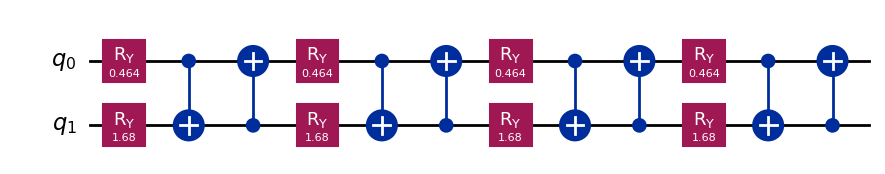

In [6]:
def create_circuit(x, theta, omega):
    qc = QuantumCircuit(N_QUBITS)
    for l in range(RC):
        layer_naive_encoding(qc, theta[l], omega[l], x)
        entangle_ring(qc)
    return qc


theta = np.ones((RC, N_QUBITS))
omega = np.ones((RC, N_QUBITS))
qc = create_circuit(X_train[0], theta, omega)
qc.draw(output="mpl")

In [7]:
def build_simulator():
    if USE_NOISE:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 1), ["ry"])
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 2), ["cx"])
        return AerSimulator(noise_model=nm)
    return StatevectorSimulator()


sv_sim = build_simulator()


def probs_from_statevector(statevector, target_qubit=0):
    probs = np.abs(statevector.data) ** 2
    p0 = 0.0
    p1 = 0.0
    for i, p in enumerate(probs):
        bit = (i >> target_qubit) & 1
        if bit == 0:
            p0 += float(p)
        else:
            p1 += float(p)
    return p0, p1


def probs_from_counts(counts, target_qubit=0):
    total = sum(counts.values()) if counts else 1
    p0 = 0
    p1 = 0
    for bitstring, c in counts.items():
        bit = bitstring[::-1][target_qubit]
        if bit == "0":
            p0 += c
        else:
            p1 += c
    return p0 / total, p1 / total


def get_probs_batch(circuits, target_qubit=0):
    if USE_NOISE:
        meas = [c.copy() for c in circuits]
        for c in meas:
            c.measure_all()
        compiled = transpile(meas, sv_sim)
        results = sv_sim.run(compiled, shots=SHOTS).result()
        return [probs_from_counts(results.get_counts(i), target_qubit=target_qubit) for i in range(len(meas))]

    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()
    return [probs_from_statevector(results.get_statevector(i), target_qubit=target_qubit) for i in range(len(circuits))]

In [8]:
def cost_function_weighted(params, X_train, y_train):
    cut = RC * N_QUBITS
    theta = params[:cut].reshape(RC, N_QUBITS)
    omega = params[cut:2 * cut].reshape(RC, N_QUBITS)
    alphas = params[2 * cut:]  # alpha_0, alpha_1

    circuits = [create_circuit(x, theta, omega) for x in X_train]
    probs = get_probs_batch(circuits, target_qubit=0)

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        f0, f1 = probs[i]
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]
        total_cost += (alphas[0] * f0 - y_expected[0]) ** 2
        total_cost += (alphas[1] * f1 - y_expected[1]) ** 2

    return 0.5 * (total_cost / len(y_train))

In [9]:
def unpack_params(params):
    cut = RC * N_QUBITS
    theta = params[:cut].reshape(RC, N_QUBITS)
    omega = params[cut:2 * cut].reshape(RC, N_QUBITS)
    alphas = params[2 * cut:]
    return theta, omega, alphas


def optimize_parameters(X_train, y_train):
    rng_local = np.random.default_rng(SEED)
    cut = RC * N_QUBITS
    init = rng_local.uniform(-np.pi, np.pi, size=2 * cut + 2)

    cache = {"cost": None}
    cost_history = []
    step = {"k": 0}

    def objective(params):
        cost = cost_function_weighted(params, X_train, y_train)
        cache["cost"] = cost
        return cost

    def cb(_):
        step["k"] += 1
        cost_history.append(cache["cost"])
        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")

    res = minimize(objective, init, method="COBYLA", callback=cb, options={"maxiter": MAXITER})

    theta_opt, omega_opt, _ = unpack_params(res.x)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res, cost_history

In [10]:
def predict_batch(X, theta, omega):
    circuits = [create_circuit(x, theta, omega) for x in X]
    probs = get_probs_batch(circuits, target_qubit=0)
    return np.array([0 if p0 >= 0.5 else 1 for p0, _ in probs])


def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred = predict_batch(X, theta, omega)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    return precision, accuracy, y_pred


theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:", precision_test)
print("Test accuracy: ", accuracy_test)

Step 001 | cost = 2.498569
Step 002 | cost = 2.349241
Step 003 | cost = 2.183937
Step 004 | cost = 2.036421
Step 005 | cost = 1.608427
Step 006 | cost = 2.078130
Step 007 | cost = 1.366848
Step 008 | cost = 1.366848
Step 009 | cost = 2.067023
Step 010 | cost = 1.595558
Step 011 | cost = 1.193497
Step 012 | cost = 1.249946
Step 013 | cost = 1.164735
Step 014 | cost = 1.125826
Step 015 | cost = 1.134278
Step 016 | cost = 1.125826
Step 017 | cost = 1.373245
Step 018 | cost = 0.996626
Step 019 | cost = 0.506000
Step 020 | cost = 0.492661
Step 021 | cost = 0.522954
Step 022 | cost = 0.888365
Step 023 | cost = 0.476232
Step 024 | cost = 0.482875
Step 025 | cost = 0.568636


KeyboardInterrupt: 

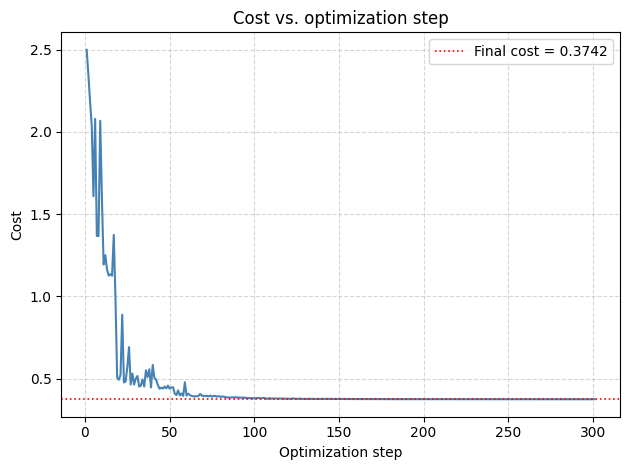

In [ ]:
ax1 = plt.subplot(1, 1, 1)
ax1.plot(range(1, len(cost_history) + 1), cost_history, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Cost vs. optimization step")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.axhline(res.fun, color="red", linestyle=":", linewidth=1.2, label=f"Final cost = {res.fun:.4f}")
ax1.legend()
plt.tight_layout()
plt.show()

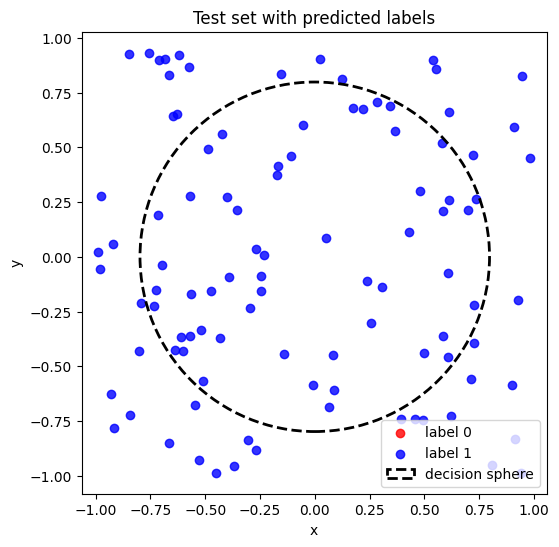

In [ ]:
if DIM == 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
    plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
    circle = plt.Circle((0, 0), radius, color="black", fill=False, linestyle="--", linewidth=2, label="decision sphere")
    plt.gca().add_patch(circle)
    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Test set with predicted labels")
    plt.legend()
    plt.show()
else:
    print("2D visualization disabled because DIM != 2")

# Baseline comparison — VQC (qiskit-machine-learning)

`VQC` (Variational Quantum Classifier) from **qiskit-machine-learning** is the canonical off-the-shelf quantum classifier.  
It uses a `FeatureMap` for data encoding and an `Ansatz` for the variational part, and exposes a scikit-learn-compatible API (`fit` / `predict` / `score`).

Here we reuse the same hyperparameters (`DIM`, `RC`, `MAXITER`, `SEED`) so the comparison is fair.

In [20]:
%pip install -q qiskit-machine-learning

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.algorithms import VQC
from scipy.optimize import minimize as scipy_minimize

vqc_cost_history = []

def cobyla_minimizer(fun, x0, **kwargs):   # **kwargs absorbs jac= and any other extra args
    def tracked_fun(params):
        val = fun(params)
        vqc_cost_history.append(float(val))
        print(f"Step {len(vqc_cost_history):03d} | VQC cost = {val:.6f}")
        return val
    return scipy_minimize(tracked_fun, x0, method="COBYLA", options={"maxiter": MAXITER})

# -- Build feature map and ansatz with the same dimensions/depth as our model --
feature_map = ZZFeatureMap(feature_dimension=DIM, reps=2)
ansatz = RealAmplitudes(num_qubits=DIM, reps=RC)

# -- Build and train the VQC --
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=cobyla_minimizer,
    sampler=StatevectorSampler(),
)

vqc.fit(X_train, y_train)

# -- Evaluate --
vqc_accuracy = vqc.score(X_test, y_test)
vqc_preds = vqc.predict(X_test)

tp_vqc = np.sum((vqc_preds == 1) & (y_test == 1))
fp_vqc = np.sum((vqc_preds == 1) & (y_test != 1))
vqc_precision = tp_vqc / (tp_vqc + fp_vqc) if (tp_vqc + fp_vqc) > 0 else 0.0

print(f"\nVQC test accuracy  : {vqc_accuracy:.4f}")
print(f"VQC test precision : {vqc_precision:.4f}")
print(f"\nOur model accuracy : {accuracy_test:.4f}")
print(f"Our model precision: {precision_test:.4f}")



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\seb92\AppData\Local\Temp\ipykernel_58072\1088152330.py:19: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=DIM, reps=2)
C:\Users\seb92\AppData\Local\Temp\ipykernel_58072\1088152330.py:20: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=DIM, reps=RC)
No gradient function provided, creating a gradient function. If your Sampler requires transpi

Note: you may need to restart the kernel to use updated packages.
Step 001 | VQC cost = 1.218018
Step 002 | VQC cost = 1.267937
Step 003 | VQC cost = 1.261041
Step 004 | VQC cost = 1.566885
Step 005 | VQC cost = 1.121287
Step 006 | VQC cost = 1.343874
Step 007 | VQC cost = 1.130461
Step 008 | VQC cost = 1.337745
Step 009 | VQC cost = 1.110311
Step 010 | VQC cost = 1.066300
Step 011 | VQC cost = 1.061217
Step 012 | VQC cost = 1.807762
Step 013 | VQC cost = 0.997690
Step 014 | VQC cost = 0.778510
Step 015 | VQC cost = 0.775169
Step 016 | VQC cost = 0.883141
Step 017 | VQC cost = 1.094517
Step 018 | VQC cost = 0.752112
Step 019 | VQC cost = 0.871601
Step 020 | VQC cost = 0.841862
Step 021 | VQC cost = 0.843117
Step 022 | VQC cost = 0.872693
Step 023 | VQC cost = 0.883344
Step 024 | VQC cost = 0.804148
Step 025 | VQC cost = 0.759786
Step 026 | VQC cost = 0.798203
Step 027 | VQC cost = 0.741693
Step 028 | VQC cost = 0.740680
Step 029 | VQC cost = 0.737246
Step 030 | VQC cost = 0.718743
Step

NameError: name 'accuracy_test' is not defined

VQC circuit (symbolic):


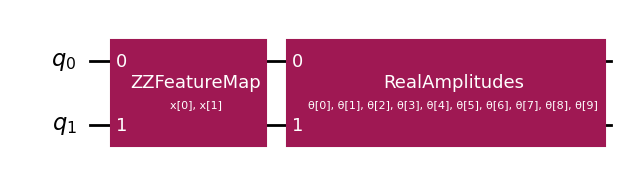

In [23]:
# Draw the VQC quantum circuit = feature_map followed by ansatz
vqc_circuit = feature_map.compose(ansatz)

print("VQC circuit (symbolic):")
vqc_circuit.draw(output="mpl", fold=120)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Left: loss curves --
ax = axes[0]
ax.plot(range(1, len(cost_history) + 1), cost_history,
        color="steelblue", linewidth=1.5, label="Our model")
ax.plot(range(1, len(vqc_cost_history) + 1), vqc_cost_history,
        color="darkorange", linewidth=1.5, label="VQC baseline")
ax.axhline(res.fun, color="steelblue", linestyle=":", linewidth=1)
ax.axhline(min(vqc_cost_history), color="darkorange", linestyle=":", linewidth=1)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Cost")
ax.set_title("Cost vs. optimization step")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# -- Right: accuracy / precision bar chart --
ax2 = axes[1]
metrics = ["Accuracy", "Precision"]
our_vals = [float(accuracy_test), float(precision_test)]
vqc_vals = [float(vqc_accuracy), float(vqc_precision)]

x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width / 2, our_vals, width, label="Our model", color="steelblue")
ax2.bar(x + width / 2, vqc_vals, width, label="VQC baseline", color="darkorange")
ax2.set_ylim(0, 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_title("Test metrics comparison")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.5)
for i, (ov, vv) in enumerate(zip(our_vals, vqc_vals)):
    ax2.text(i - width / 2, ov + 0.02, f"{ov:.3f}", ha="center", fontsize=9)
    ax2.text(i + width / 2, vv + 0.02, f"{vv:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
